In [159]:
import pandas as pd
from os.path import join
from random import sample
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Carga de Datos

In [160]:
#dataframe para el archivo PIB
path_pib = join('data', 'pib2020-2025.csv')
df_pib = pd.read_csv(path_pib)

path_life_exp = join('data', 'WHO_life_expectancy.csv')
df_life_exp = pd.read_csv(path_life_exp)

print("Dataframes creados:")
display(df_pib.sample(5).sort_index())
display(df_life_exp.sample(5).sort_index())

Dataframes creados:


,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
50,Ecuador,95865,107179.0,116133.0,121147.0,121728.0,125677.0
69,Guinea,14089,16320.0,19589.0,22750.0,25758.0,30094.0
81,Ireland,436205,531660.0,549003.0,551554.0,577216.0,598840.0
146,San Marino,1543,1857.0,1833.0,2003.0,2063.0,2047.0


,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value
8601,WHOSIS_000015,Life expectancy at age 60 (years),SEAR,South-East Asia,Country,MMR,Myanmar,Year,2014,Sex,Female,19.2 [18.7-19.8]
14601,WHOSIS_000001,Life expectancy at birth (years),SEAR,South-East Asia,Country,TLS,Timor-Leste,Year,2008,Sex,Male,65.7 [64.8-66.6]
19822,WHOSIS_000015,Life expectancy at age 60 (years),WPR,Western Pacific,Country,TON,Tonga,Year,2004,Sex,Female,20.7 [20.3-21.1]
21189,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,KEN,Kenya,Year,2002,Sex,Female,55.7 [54.8-56.8]
22588,WHOSIS_000001,Life expectancy at birth (years),WPR,Western Pacific,Country,BRN,Brunei Darussalam,Year,2001,Sex,Male,74.4 [74.0-74.7]


In [161]:
print("="*15 + " Información de PIB: " + "="*15)
display(df_pib.info())
print("="*53 + "\n")

print("="*10 + " Información de Life Expentacy: " + "="*11)
display(df_life_exp.info())
print("="*53 + "\n")

=============== Información de PIB: ===============
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  196 non-null    object 
 1   2020     196 non-null    int64  
 2   2021     194 non-null    float64
 3   2022     194 non-null    float64
 4   2023     194 non-null    float64
 5   2024     192 non-null    float64
 6   2025     189 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.8+ KB


None


========== Información de Life Expentacy: ===========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24420 entries, 0 to 24419
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   IndicatorCode        24420 non-null  object
 1   Indicator            24420 non-null  object
 2   ParentLocationCode   24420 non-null  object
 3   ParentLocation       24420 non-null  object
 4   Location type        24420 non-null  object
 5   SpatialDimValueCode  24420 non-null  object
 6   Location             24420 non-null  object
 7   Period type          24420 non-null  object
 8   Period               24420 non-null  int64 
 9   Dim1 type            24420 non-null  object
 10  Dim1                 24420 non-null  object
 11  Value                24420 non-null  object
dtypes: int64(1), object(11)
memory usage: 2.2+ MB


None

## 2. Análisis de valores nulos

Notemos que `df_pib` tiene filas con valores NaN, en cambio, `df_life_expectacy` no. Corroboraremos:

In [162]:
nulos_pib = df_pib.isna().sum()
nulos_life = df_life_exp.isna().sum()
display(nulos_pib, nulos_life)

Country    0
2020       0
2021       2
2022       2
2023       2
2024       4
2025       7
dtype: int64

IndicatorCode          0
Indicator              0
ParentLocationCode     0
ParentLocation         0
Location type          0
SpatialDimValueCode    0
Location               0
Period type            0
Period                 0
Dim1 type              0
Dim1                   0
Value                  0
dtype: int64

Corroboramos que `df_pib` tiene **valores nulos**, por lo que visualizaremos esas filas:

In [163]:
df_pib[df_pib.isna().any(axis=1)]

,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
54,Eritrea,1982,NaN,NaN,NaN,NaN,NaN
96,Lebanon,24976,19782.0,24748.0,23607.0,28280.0,NaN
131,Pakistan,300410,348481.0,374850.0,337754.0,373078.0,NaN
161,Sri Lanka,84304,88609.0,74584.0,83723.0,98964.0,NaN
169,Syria,60043,NaN,NaN,NaN,NaN,NaN
192,Palestine,15532,18109.0,19166.0,17848.0,NaN,NaN


In [164]:
# Crea un nuevo dataframe solo con los años que están completos, POSIBLE CASO QUE NOS PIDAN
df_pib_completo = df_pib.drop(columns=['2024', '2025'])

#Nos podrían pedir que mantuvieramos esos NaN, punto a tener muy en cuenta.

## 3. Exploracion de tipos de datos

In [165]:
df_pib.dtypes

Country     object
2020         int64
2021       float64
2022       float64
2023       float64
2024       float64
2025       float64
dtype: object

In [166]:
df_life_exp.dtypes

IndicatorCode          object
Indicator              object
ParentLocationCode     object
ParentLocation         object
Location type          object
SpatialDimValueCode    object
Location               object
Period type            object
Period                  int64
Dim1 type              object
Dim1                   object
Value                  object
dtype: object

In [167]:
display(df_pib.sample(3), df_life_exp.sample(3))

,Country,2020,2021,2022,2023,2024,2025
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
123,Netherlands,931814,1055173.0,1047364.0,1154694.0,1227174.0,1272011.0
27,Burkina Faso,17837,19747.0,19588.0,21181.0,23975.0,27056.0


,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value
4075,WHOSIS_000015,Life expectancy at age 60 (years),AFR,Africa,Country,NAM,Namibia,Year,2018,Sex,Female,18.2 [17.5-19.0]
2382,WHOSIS_000001,Life expectancy at birth (years),AMR,Americas,Country,GUY,Guyana,Year,2019,Sex,Both sexes,68.7 [68.0-69.5]
15980,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,HUN,Hungary,Year,2007,Sex,Female,77.5 [77.5-77.6]


Notemos que `Dim1 type` es la **descripción de lo que encontraremos** en `dim1`. Esto será util más adelante para renombrar columnas.

### 3.1 Variables categóricas - POR DETERMINAR

- Para simplicar un poco el proceso, usamos `select_dtypes` para que busque las columnas de **type=object**.

In [168]:
# Seleccionar solo las columnas de tipo 'object' (texto)
object_cols = df_life_exp.select_dtypes(include='object').columns

print("Columna (Tipo 'object')   | Número de Valores Únicos")
print('-'*52)
for col in object_cols:
    # .nunique() -> CONTEO
    num_unique = df_life_exp[col].nunique()

    # ":<25" es solo formato para alinear el texto
    print(f"{col:<25} | {num_unique}")
print('-'*52)

Columna (Tipo 'object')   | Número de Valores Únicos
----------------------------------------------------
IndicatorCode             | 2
Indicator                 | 2
ParentLocationCode        | 6
ParentLocation            | 6
Location type             | 1
SpatialDimValueCode       | 185
Location                  | 185
Period type               | 1
Dim1 type                 | 1
Dim1                      | 3
Value                     | 9937
----------------------------------------------------


Las columnas `IndicatorCode`, `Indicator`, `ParentLocationCode`, `ParentLocation`, `Location type`, `Period type`, `Dim1 type` y `Dim1` son perfectas para llevarlas a **type=category** dado que contienne muy pocas entradas distintas de sí mísmas y así reducimos espacio en memoria.

Más adelante se estimará si es necesario pasar alguna a categoría.

Ahora creamos `df_life_exp_renamed` con columnas renombradas para una mayor claridad. 

In [169]:
df_life_exp_renamed = df_life_exp.rename(columns={
    'Location': 'Country',
    'ParentLocation': 'Region',
    'Period': 'Year',
    'Dim1': 'Sex(ex Dim1)',
    'Value': 'Life_Expectancy_Raw'
})

display(df_life_exp_renamed.sample(5))

,IndicatorCode,Indicator,ParentLocationCode,Region,Location type,SpatialDimValueCode,Country,Period type,Year,Dim1 type,Sex(ex Dim1),Life_Expectancy_Raw
3688,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,SYC,Seychelles,Year,2018,Sex,Female,76.6 [76.4-77.0]
3321,WHOSIS_000015,Life expectancy at age 60 (years),WPR,Western Pacific,Country,JPN,Japan,Year,2019,Sex,Both sexes,26.7 [26.6-26.7]
5544,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,ESP,Spain,Year,2017,Sex,Female,26.9 [26.9-27.0]
23327,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,ZWE,Zimbabwe,Year,2000,Sex,Female,46.7 [44.7-48.4]
6302,WHOSIS_000015,Life expectancy at age 60 (years),AFR,Africa,Country,CIV,Cote d'Ivoire,Year,2016,Sex,Female,18.2 [17.6-18.9]


## 4. EDA (Análisis exploratorio de Datos)
- Exploration data analisis
### Sobre `df_pib`

In [170]:
#Vamos a hacer un melt para poder asignar las columnas a graficar
df_pib_para_graficar = df_pib.melt(
    id_vars=['Country'],    # Columna que NO se transforma
    var_name='Year',        # Nombre para la nueva columna de "años"
    value_name='PIB'        # Nombre para la nueva columna de "valores" (PIB)
)

print("Dataframe df_pib_plot creado (primeras 5 filas)")
display(df_pib_para_graficar.sample(5).sort_index())

Dataframe df_pib_plot creado (primeras 5 filas)


,Country,Year,PIB
45,Czech Republic,2020,251110.0
60,France,2020,2645806.0
275,Iran,2021,289294.0
567,Togo,2022,8144.0
1120,Puerto Rico,2025,122522.0


/var/folders/hf/z4nqpl692qq20c0yrl9q93r40000gn/T/ipykernel_9824/1375186290.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pib_para_graficar, x='Year', y='PIB', palette='viridis')


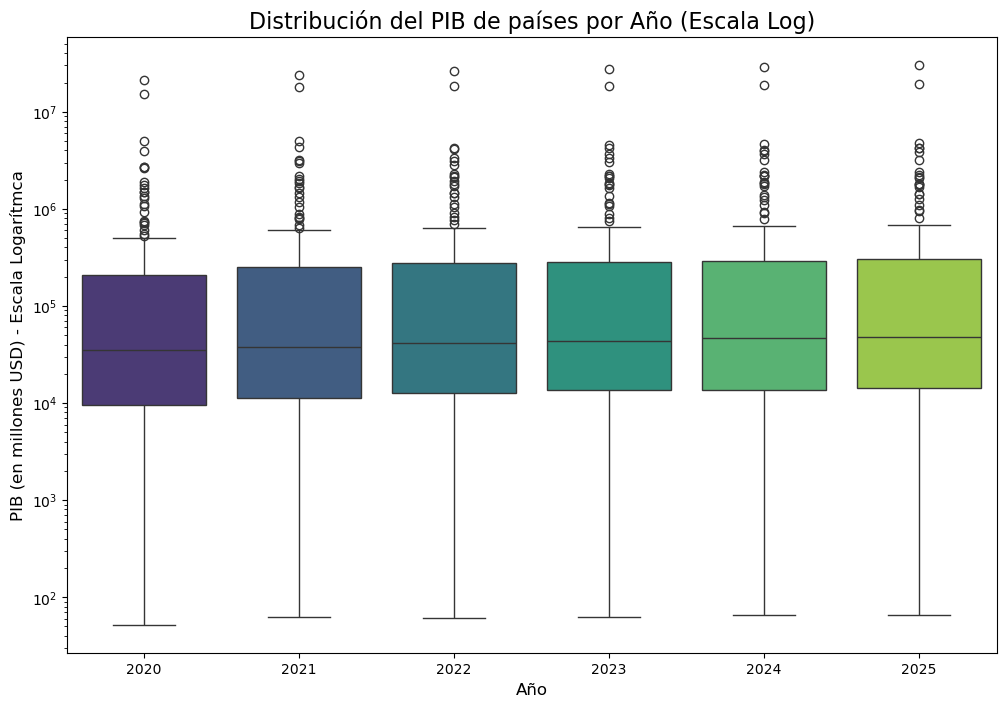

In [171]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_pib_para_graficar, x='Year', y='PIB', palette='viridis')

# Usamos una escala logarítmica para poder ver la distribución correcta, sin sesgos por outliers
plt.yscale('log')

plt.title('Distribución del PIB de países por Año (Escala Log)', fontsize=16)
plt.xlabel('Año', fontsize=12)
plt.ylabel('PIB (en millones USD) - Escala Logarítmca', fontsize=12)

plt.show()

/var/folders/hf/z4nqpl692qq20c0yrl9q93r40000gn/T/ipykernel_9824/3736617048.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_5_por_ano = df_pib_para_graficar.groupby('Year').apply(


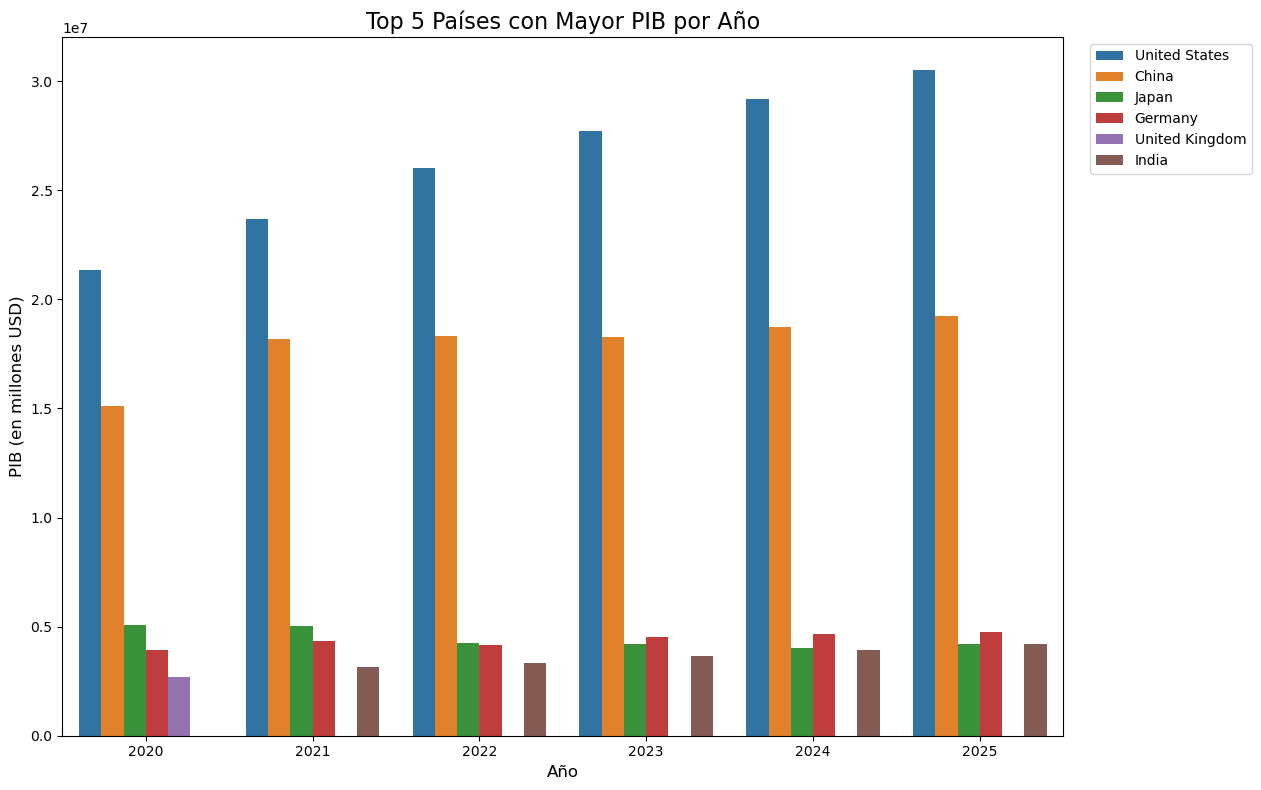

In [172]:
df_pib_para_graficar = df_pib_para_graficar.dropna(subset=['PIB'])

# --- Paso 4: Encontrar el Top 5 POR AÑO (El paso más simple y clave) ---
# Agrupamos por 'Year'
# Para cada grupo (año), aplicamos una función (lambda) que toma el mayor PIB
# .reset_index(drop=True) limpia el índice para que Seaborn lo lea bien.
top_5_por_ano = df_pib_para_graficar.groupby('Year').apply(
    lambda x: x.nlargest(5, 'PIB')
).reset_index(drop=True) #nlargest arroja las n filas con los valores PIB más altos


# Gráfico de Barras Agrupadas
plt.figure(figsize=(15, 8))

sns.barplot(
    data=top_5_por_ano,
    x='Year',       # Años en el eje X
    y='PIB',        # PIB en el eje Y
    hue='Country'   # Barras de colores agrupadas por País
)

plt.title('Top 5 Países con Mayor PIB por Año', fontsize=16)
plt.xlabel('Año', fontsize=12)
plt.ylabel('PIB (en millones USD)', fontsize=12)


# (1.02, 1) significa "un poco a la derecha y arriba del gráfico"
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# Ajustar el layout para que la leyenda no se corte
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Deja espacio a la derecha (85% de ancho)

Lo que el gráfico expone es un **cambio económico clave**: aunque el **Reino Unido** se mantenía en el Top 5 en 2020, fue desplazado por la India a partir de 2021. Esto no significa necesariamente que la economía británica colapsara, también podría deberse a que la economía de la India experimentó un crecimiento mucho más acelerado, superando al Reino Unido y consolidándose como la quinta economía más grande del mundo, un hecho que se ve reflejado en los datos de los años siguientes.

### Sobre `df_life_exp`

In [173]:
clean_df_life = df_life_exp_renamed.copy()
display(clean_df_life.sample(5))

,IndicatorCode,Indicator,ParentLocationCode,Region,Location type,SpatialDimValueCode,Country,Period type,Year,Dim1 type,Sex(ex Dim1),Life_Expectancy_Raw
6070,WHOSIS_000001,Life expectancy at birth (years),WPR,Western Pacific,Country,KOR,Republic of Korea,Year,2016,Sex,Both sexes,82.7 [82.7-82.8]
5173,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,SRB,Serbia,Year,2017,Sex,Male,17.8 [17.8-17.9]
8823,WHOSIS_000015,Life expectancy at age 60 (years),WPR,Western Pacific,Country,NZL,New Zealand,Year,2014,Sex,Both sexes,24.2 [24.2-24.3]
21263,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,COM,Comoros,Year,2002,Sex,Female,63.9 [63.1-64.8]
15439,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,SVN,Slovenia,Year,2008,Sex,Both sexes,22.4 [22.3-22.6]


In [174]:
# limpiamos life_expentacy
clean_df_life['Life_Expectancy'] = clean_df_life['Life_Expectancy_Raw'].str.split(' ').str[0]

# convertir ese texto a un número (float)
clean_df_life['Life_Expectancy'] = clean_df_life['Life_Expectancy'].astype(float)

display(clean_df_life.head())
print("\n--- Tipos de datos (info) ---")
clean_df_life.info()

,IndicatorCode,Indicator,ParentLocationCode,Region,Location type,SpatialDimValueCode,Country,Period type,Year,Dim1 type,Sex(ex Dim1),Life_Expectancy_Raw,Life_Expectancy
0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Male,48.7 [47.8-49.7],48.7
1,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,CAF,Central African Republic,Year,2021,Sex,Male,49.6 [48.5-50.9],49.6
2,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Both sexes,51.5 [50.5-52.6],51.5
3,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,SWZ,Eswatini,Year,2021,Sex,Male,51.6 [50.7-52.8],51.6
4,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,SOM,Somalia,Year,2021,Sex,Male,51.7 [50.6-53.1],51.7



--- Tipos de datos (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24420 entries, 0 to 24419
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   IndicatorCode        24420 non-null  object 
 1   Indicator            24420 non-null  object 
 2   ParentLocationCode   24420 non-null  object 
 3   Region               24420 non-null  object 
 4   Location type        24420 non-null  object 
 5   SpatialDimValueCode  24420 non-null  object 
 6   Country              24420 non-null  object 
 7   Period type          24420 non-null  object 
 8   Year                 24420 non-null  int64  
 9   Dim1 type            24420 non-null  object 
 10  Sex(ex Dim1)         24420 non-null  object 
 11  Life_Expectancy_Raw  24420 non-null  object 
 12  Life_Expectancy      24420 non-null  float64
dtypes: float64(1), int64(1), object(11)
memory usage: 2.4+ MB


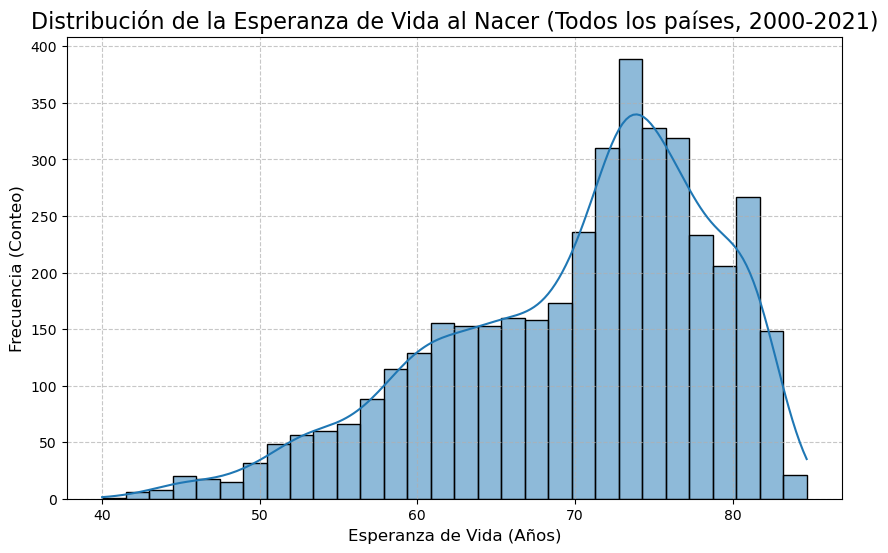

In [175]:
#creamos un DataFrame_Life_expentacy para graficar la esperanza de vida al nacer por ambos sexos.
df_le_filtered = clean_df_life[(clean_df_life['Indicator'] == 'Life expectancy at birth (years)') & (clean_df_life['Sex(ex Dim1)'] == 'Both sexes')].copy()

# --- Paso 2.2: Histograma de Life_Expectancy ---
# Por qué: Para ver la distribución de nuestra variable objetivo.
# ¿Dónde se concentran los países? ¿Es normal la distribución?
# Acción: Un histograma de la columna numérica 'Life_Expectancy'.
plt.figure(figsize=(10, 6))
sns.histplot(df_le_filtered['Life_Expectancy'], bins=30, kde=True)
plt.grid(True, zorder=0, linestyle='--', alpha=0.7)
plt.title('Distribución de la Esperanza de Vida al Nacer (Todos los países, 2000-2021)', fontsize=16)
plt.xlabel('Esperanza de Vida (Años)', fontsize=12)
plt.ylabel('Frecuencia (Conteo)', fontsize=12)
plt.show()


El gráfico de la esperanza de vida **no muestra una distribución normal**. Lo que vemos es un claro sesgo a la izquierda (o "sesgo negativo"), si bien la gran mayoría de los países se agrupan en el lado derecho con una alta esperanza de vida (el "cuerpo"), hay una "cola" de países con valores bajos que se extiende hacia la izquierda. Esta cola de **valores bajos "arrastra" la media (el promedio) haciendo que sea menor que la mediana y la moda**, a diferencia de una campana de Gauss perfecta donde las tres medidas serían iguales.

/var/folders/hf/z4nqpl692qq20c0yrl9q93r40000gn/T/ipykernel_9824/3374609249.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_le_filtered, y='Region', palette='viridis', order = df_le_filtered['Region'].value_counts().index)


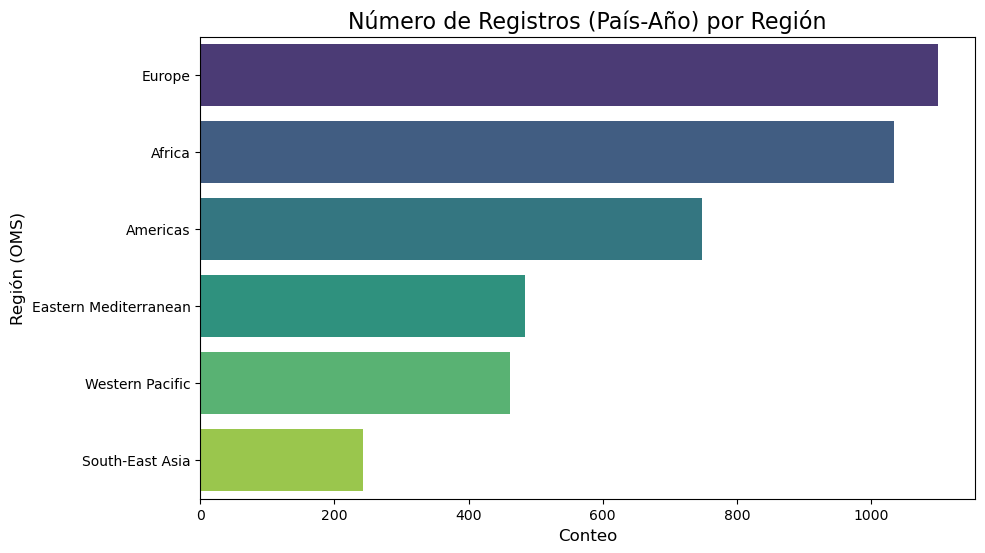

In [176]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_le_filtered, y='Region', palette='viridis', order = df_le_filtered['Region'].value_counts().index)
plt.title('Número de Registros (País-Año) por Región', fontsize=16)
plt.xlabel('Conteo', fontsize=12)
plt.ylabel('Región (OMS)', fontsize=12)
"""
plt.savefig('le_region_count_v2.png')
print("Gráfico 'le_region_count_v2.png' generado.")
"""
plt.show()

El gráfico de conteo por región muestra una distribución de datos desigual, donde África (AFR) y Europa (EUR) aportan la mayor cantidad de registros "País-Año". Esto no es un error, sino que refleja el mayor número de países miembros de la OMS en esas regiones. La implicación clave es que cualquier análisis "global", como el cálculo de la esperanza de vida promedio mundial, estará fuertemente influenciado por los datos de África, ya que esta región tiene el mayor "peso" (más puntos de datos) en el conjunto total.

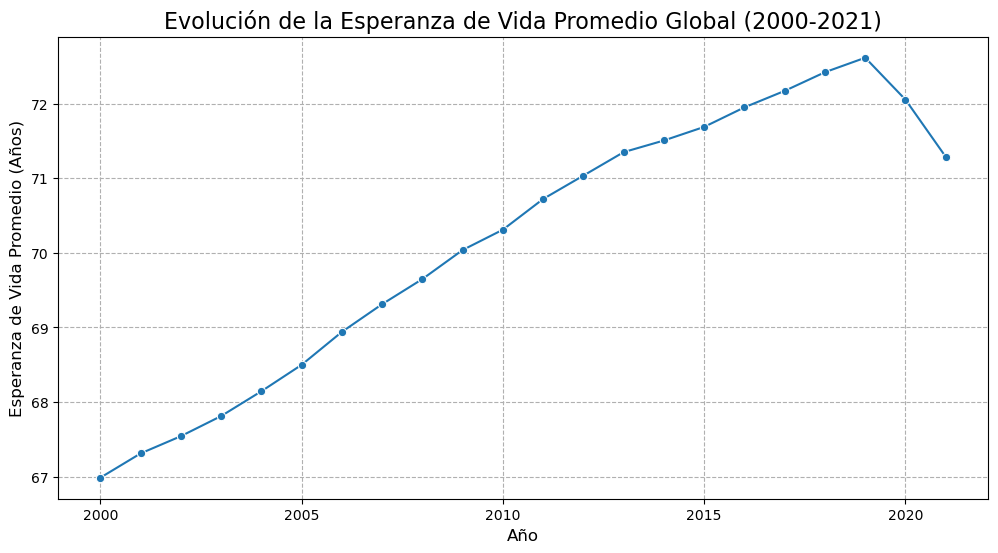

In [177]:
avg_le_by_year = df_le_filtered.groupby('Year')['Life_Expectancy'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_le_by_year, x='Year', y='Life_Expectancy', marker='o')
plt.title('Evolución de la Esperanza de Vida Promedio Global (2000-2021)', fontsize=16)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Esperanza de Vida Promedio (Años)', fontsize=12)
plt.grid(True, linestyle='--')
plt.show()

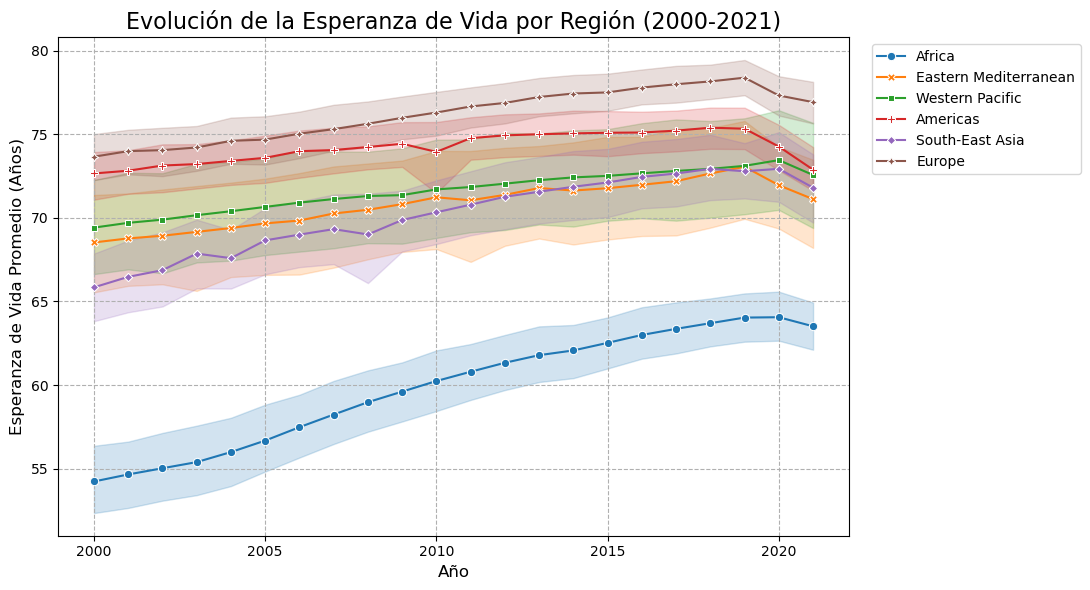

In [178]:
# --- Paso 3.3: Evolución del Tiempo POR Región (Multivariado) ---
# Por qué: Ver si todas las regiones han mejorado al mismo ritmo.
# Acción: Un gráfico de línea con 'Year' en X, 'Life_Expectancy' en Y, y 'hue' (color) por 'Region'.
plt.figure(figsize=(13, 6))
sns.lineplot(data=df_le_filtered, x='Year', y='Life_Expectancy', hue='Region', style='Region', markers=True, dashes=False)
plt.title('Evolución de la Esperanza de Vida por Región (2000-2021)', fontsize=16)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Esperanza de Vida Promedio (Años)', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--')
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

Nuevamente se repite el fenómeno Europeo, donde el viejo continente obtiene la mayor esperanza de vida en cada año. Lo que probablemente esté asociado a una fuerte relación con el PIB de cada país europeo, por lo que esto nos da un indicio de variables positivamente relacionadas. Luego haremos un análisis sobre esta hipótesis.

Sin embargo, hay que considerar unos factores socio-mundiales:
1. **El Impacto de la Pandemia (La Caída de 2019-2021)** 📉:

    La observación más dramática es la abrupta caída en la esperanza de vida para la mayoría de las regiones entre 2019 y 2021. Este evento revierte una tendencia de 20 años de crecimiento constante y es, casi con seguridad, el impacto directo de la pandemia de COVID-19 en la mortalidad global.


1. **El Impacto Desigual de la Pandemia** 🌍: 
    
    Las Américas (AMR) y el Sudeste Asiático (SEAR) muestran los descensos más pronunciados, borrando varios años de progreso de un solo golpe.

    En contraste, el Pacífico Occidental (WPR) y África (AFR) se muestran notablemente más resilientes en esta métrica, casi sin perder terreno. Esto añade complejidad a tu hipótesis del PIB: las Américas (una región con muchos países de ingresos altos y medios) sufrieron un golpe mucho más duro que África (la región con la mediana de ingresos más baja). Esto sugiere que otros factores (como la política de salud pública, la demografía o la infraestructura sanitaria) jugaron un papel crucial.

1. **La Tendencia de "Convergencia" (2000-2019) 📈:**

    Si miras el período antes de la pandemia (2000-2019), la línea de África (AFR), aunque es la más baja, tiene una pendiente (slope) visiblemente más pronunciada que la de Europa (EUR) o las Américas (AMR).

    Esto indica que África estaba experimentando el crecimiento más acelerado en esperanza de vida. La brecha entre la región más baja y la más alta se estaba cerrando lentamente, mostrando una tendencia a la convergencia global que fue trágicamente interrumpida en 2020.


### 5. Unificacion de dataframes

In [179]:
display(clean_df_life.head())
display(df_pib.head())

,IndicatorCode,Indicator,ParentLocationCode,Region,Location type,SpatialDimValueCode,Country,Period type,Year,Dim1 type,Sex(ex Dim1),Life_Expectancy_Raw,Life_Expectancy
0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Male,48.7 [47.8-49.7],48.7
1,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,CAF,Central African Republic,Year,2021,Sex,Male,49.6 [48.5-50.9],49.6
2,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Both sexes,51.5 [50.5-52.6],51.5
3,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,SWZ,Eswatini,Year,2021,Sex,Male,51.6 [50.7-52.8],51.6
4,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,SOM,Somalia,Year,2021,Sex,Male,51.7 [50.6-53.1],51.7


,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0


In [ ]:
df_pib_long = df_pib.melt(id_vars='Country', var_name='Year', value_name='PIB')
df_pib_long['Year'] = df_pib_long['Year'].astype(int)

df_merged = clean_df_life.merge(df_pib_long, on=['Country', 'Year'], how='left')
(df_merged.head())

,IndicatorCode,Indicator,ParentLocationCode,Region,Location type,SpatialDimValueCode,Country,Period type,Year,Dim1 type,Sex(ex Dim1),Life_Expectancy_Raw,Life_Expectancy,PIB
0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Male,48.7 [47.8-49.7],48.7,2445.0
1,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,CAF,Central African Republic,Year,2021,Sex,Male,49.6 [48.5-50.9],49.6,2585.0
2,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Both sexes,51.5 [50.5-52.6],51.5,2445.0
3,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,SWZ,Eswatini,Year,2021,Sex,Male,51.6 [50.7-52.8],51.6,4851.0
4,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,SOM,Somalia,Year,2021,Sex,Male,51.7 [50.6-53.1],51.7,9484.0


In [181]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24420 entries, 0 to 24419
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   IndicatorCode        24420 non-null  object 
 1   Indicator            24420 non-null  object 
 2   ParentLocationCode   24420 non-null  object 
 3   Region               24420 non-null  object 
 4   Location type        24420 non-null  object 
 5   SpatialDimValueCode  24420 non-null  object 
 6   Country              24420 non-null  object 
 7   Period type          24420 non-null  object 
 8   Year                 24420 non-null  int64  
 9   Dim1 type            24420 non-null  object 
 10  Sex(ex Dim1)         24420 non-null  object 
 11  Life_Expectancy_Raw  24420 non-null  object 
 12  Life_Expectancy      24420 non-null  float64
 13  PIB                  1926 non-null   float64
dtypes: float64(2), int64(1), object(11)
memory usage: 2.6+ MB
